In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

In [2]:
NSIDE = 32
print(
    "Approximate resolution at NSIDE {} is {:.2} deg".format(
        NSIDE, hp.nside2resol(NSIDE, arcmin=True) / 60
    )
)

Approximate resolution at NSIDE 32 is 1.8 deg


12288


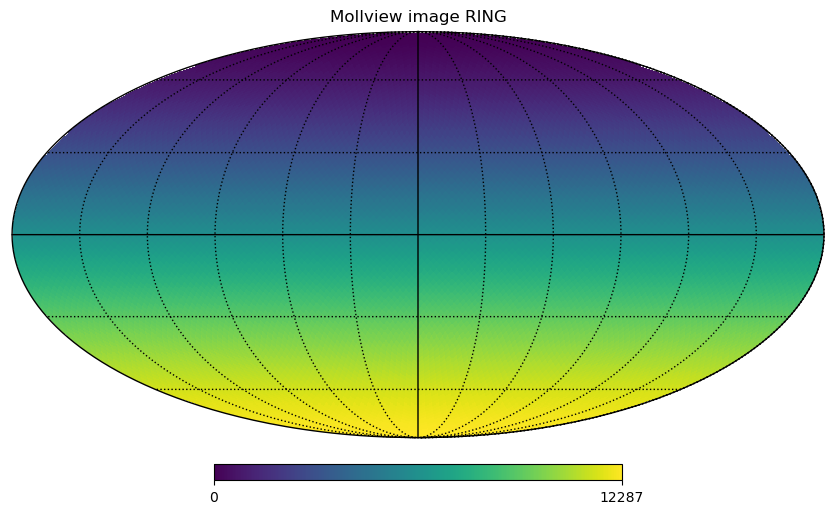

In [3]:
NPIX = hp.nside2npix(NSIDE)
print(NPIX)
m = np.arange(NPIX)
hp.mollview(m, title="Mollview image RING")
hp.graticule()

In [ ]:
def Int_I_est(alpha, beta, gamma, kappa, nside = 8):
    npix = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(npix))
    dOmega = hp.nside2pixarea(nside)

    a = np.sin(alpha) * np.sin(theta)
    c = np.sin(beta) * np.sin(theta)
    b = np.cos(alpha) * np.cos(theta)
    d = np.cos(beta) * np.cos(theta)

    P = a * np.cos(phi) + b
    Q = c * np.cos(phi - gamma) + d
    K = (P - 1)*(Q - 1)
    F = K * np.exp(kappa * np.cos(theta))
    return 1/(4*np.pi) * np.sum(dOmega * F)

: 

In [ ]:
def Int_I_theory(alpha, beta, gamma, kappa):
    cos_xi = np.cos(alpha) * np.cos(beta) + np.sin(alpha) * np.sin(beta) * np.cos(gamma)
    sh_kappa, ch_kappa = np.sinh(kappa), np.cosh(kappa)
    cos_alpha, cos_beta = np.cos(alpha), np.cos(beta)
    return (
        sh_kappa/kappa + (3 * (kappa*ch_kappa - sh_kappa)/kappa**3) * (cos_xi/3) + \
        (sh_kappa/kappa - 3 * (kappa*ch_kappa - sh_kappa)/kappa**3) * (cos_alpha * cos_beta) - \
        (kappa*ch_kappa - sh_kappa)/kappa**2 * (cos_alpha + cos_beta)
    )

In [ ]:
rng = np.random.default_rng(seed=42)
N = 100
alpha = rng.uniform(0, np.pi)
beta =  rng.uniform(0, np.pi)
gamma =  rng.uniform(0, 2*np.pi)
kappa =  rng.uniform(0, 2)

In [ ]:
i_est = Int_I_est(alpha, beta, gamma, kappa, nside=1000)
i_the = Int_I_theory(alpha, beta, gamma, kappa)
print(i_est, i_the)
print(f"dI = {np.abs(i_est - i_the)}")

In [ ]:
def Int_J_est(alpha, beta, gamma, kappa, nside = 8):
    npix = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(npix))
    dOmega = hp.nside2pixarea(nside)

    a = np.sin(alpha) * np.sin(theta)
    c = np.sin(beta) * np.sin(theta)
    b = np.cos(alpha) * np.cos(theta)
    d = np.cos(beta) * np.cos(theta)
    f = np.sin(alpha)

    P_m = f * np.sin(phi)
    P_o = a * np.cos(phi) + b
    Q_o = c * np.cos(phi - gamma) + d
    K = 2 * P_m**2 * (Q_o - 1)/(P_o + 1)
    F = K * np.exp(kappa * np.cos(theta))
    return 1/(4*np.pi) * np.sum(dOmega * F)

In [ ]:
from scipy.special import expi 
def Int_J_theory(alpha, beta, gamma, kappa):
    c = np.cos(alpha) * np.cos(beta) + np.sin(alpha) * np.sin(beta) * np.cos(gamma)
    a, b = np.cos(alpha), np.cos(beta)
    k = kappa
    R = (c - a*b)/(2*(1-a**2))
    return (
        + (1-a) * (b + (a*b + c)/2) * (np.sinh(k)/k + a * (np.cosh(k) - np.exp(-k*a))/(k*a))/(1+a) \
        - (1+a) * (b - (a*b + c)/2) * (np.sinh(k)/k - a * (np.cosh(k) - np.exp(-k*a))/(k*a))/(1-a) \
        + (1-a) * (1+a+b+c)/(1+a) * np.exp(-k) * (expi(+k*(1-a)) - expi(+2*k)) \
        + (1+a) * (1-a-b+c)/(1-a) * np.exp(+k) * (expi(-k*(1+a)) - expi(-2*k))
    )

In [ ]:
for k in range(2):
    rng = np.random.default_rng(seed=k)
    N = 100
    alpha = rng.uniform(0, np.pi)
    beta =  rng.uniform(0, np.pi)
    gamma =  rng.uniform(0, 2*np.pi)
    kappa =  rng.uniform(0, 2)

    i_est = Int_J_est(alpha, beta, gamma, kappa, nside=1000)
    i_the = Int_J_theory(alpha, beta, gamma, kappa)
    print(i_est, i_the)
    print(f"dI = {np.abs(i_est - i_the)}")

In [ ]:
def Int_K_est(alpha, beta, gamma, kappa, nside = 8):
    npix = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(npix))
    dOmega = hp.nside2pixarea(nside)

    a = np.sin(alpha) * np.sin(theta)
    c = np.sin(beta) * np.sin(theta)
    b = np.cos(alpha) * np.cos(theta)
    d = np.cos(beta) * np.cos(theta)
    g = np.sin(beta)

    Q_m = g * np.sin(phi - gamma)
    P_o = a * np.cos(phi) + b
    Q_o = c * np.cos(phi - gamma) + d
    K = 2 * Q_m**2 * (P_o - 1)/(Q_o + 1)
    F = K * np.exp(kappa * np.cos(theta))
    return 1/(4*np.pi) * np.sum(dOmega * F)

In [ ]:
from scipy.special import expi 
def Int_K_theory(alpha, beta, gamma, kappa):
    c = np.cos(alpha) * np.cos(beta) + np.sin(alpha) * np.sin(beta) * np.cos(gamma)
    a, b = np.cos(alpha), np.cos(beta)
    k = kappa
    R = (c - a*b)/(2*(1-a**2))
    return (
        + (1-b) * (a + (a*b + c)/2) * (np.sinh(k)/k + b * (np.cosh(k) - np.exp(-k*b))/(k*b))/(1+b) \
        - (1+b) * (a - (a*b + c)/2) * (np.sinh(k)/k - b * (np.cosh(k) - np.exp(-k*b))/(k*b))/(1-b) \
        + (1-b) * (1+a+b+c)/(1+b) * np.exp(-k) * (expi(+k*(1-b)) - expi(+2*k)) \
        + (1+b) * (1-a-b+c)/(1-b) * np.exp(+k) * (expi(-k*(1+b)) - expi(-2*k))
    )

In [ ]:
for k in range(2):
    rng = np.random.default_rng(seed=k)
    N = 100
    alpha = rng.uniform(0, np.pi)
    beta =  rng.uniform(0, np.pi)
    gamma =  rng.uniform(0, 2*np.pi)
    kappa =  rng.uniform(0, 2)

    i_est = Int_K_est(alpha, beta, gamma, kappa, nside=1000)
    i_the = Int_K_theory(alpha, beta, gamma, kappa)
    print(i_est, i_the)
    print(f"dI = {np.abs(i_est - i_the)}")

In [ ]:
def Int_H_est(alpha, beta, gamma, kappa, nside = 8):
    npix = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(npix))
    dOmega = hp.nside2pixarea(nside)

    a = np.sin(alpha) * np.sin(theta)
    b = np.cos(alpha) * np.cos(theta)
    c = np.sin(beta) * np.sin(theta)
    d = np.cos(beta) * np.cos(theta)
    h = np.sin(alpha) * np.cos(theta)
    s = np.cos(alpha) * np.sin(theta)
    k = np.sin(beta) * np.cos(theta)
    t = np.cos(beta) * np.sin(theta)
    f = np.sin(alpha)
    g = np.sin(beta)

    P_o = a * np.cos(phi) + b
    Q_o = c * np.cos(phi - gamma) + d
    P_n = h * np.cos(phi) - s
    Q_n = k * np.cos(phi - gamma) - t
    P_m = f * np.sin(phi)
    Q_m = g * np.sin(phi - gamma)

    K = 4 * P_m*Q_m * (P_m*Q_m + P_n*Q_n)/((1 + P_o) * (1 + Q_o))
    F = K * np.exp(kappa * np.cos(theta))
    return 1/(4*np.pi) * np.sum(dOmega * F)

In [ ]:
from scipy.special import expi 
def Int_H_theory(alpha, beta, gamma, kappa):
    c = np.cos(alpha) * np.cos(beta) + np.sin(alpha) * np.sin(beta) * np.cos(gamma)
    a, b = np.cos(alpha), np.cos(beta)
    k = kappa
    t = (a + b)/(1+c)
    s = np.sqrt(1 + 2*a*b*c - c**2 - a**2 - b**2)/(1+c)
    r = (t + 1j*s)

    return (
        + 2*(a*b - c)*np.sinh(k)/k
        + 2*(a*b - c)/(1+a) * np.exp(-k) * (expi(+k*(1-a)) - expi(+2*k)) 
        + 2*(a*b - c)/(1+b) * np.exp(-k) * (expi(+k*(1-b)) - expi(+2*k)) 
        + 2*(a*b - c)/(1-b) * np.exp(+k) * (expi(-k*(1+b)) - expi(-2*k))
        + 2*(a*b - c)/(1-a) * np.exp(+k) * (expi(-k*(1+a)) - expi(-2*k))  
        - (1-c) * np.exp(-k) * (expi(+k*(1-a)) - expi(+2*k)) 
        - (1-c) * np.exp(-k) * (expi(+k*(1-b)) - expi(+2*k)) 
        - (1-c) * np.exp(+k) * (expi(-k*(1+a)) - expi(-2*k))
        - (1-c) * np.exp(+k) * (expi(-k*(1+b)) - expi(-2*k))
        - (a-b) * np.exp(+k) * (expi(-k*(1+a)) - expi(-k*(1+b)))
        - (a-b) * np.exp(-k) * (expi(+k*(1-b)) - expi(+k*(1-a)))
        - (1-c) * 2 * np.real(np.exp(-k*r) * (expi(+k*(r-1)) + expi(+k*(r+1))))
        + (1-c) * 2 * np.real(np.exp(-k*r) * (expi(+k*(r-a)) + expi(+k*(r-b))))
    )

In [ ]:
for k in range(2):
    rng = np.random.default_rng(seed=k)
    N = 100
    alpha = rng.uniform(0, np.pi)
    beta =  rng.uniform(0, np.pi)
    gamma =  rng.uniform(0, 2*np.pi)
    kappa =  rng.uniform(0, 2)

    i_est = Int_H_est(alpha, beta, gamma, kappa, nside=1000)
    i_the = Int_H_theory(alpha, beta, gamma, kappa)
    print(i_est, i_the)
    print(f"dI = {np.abs(i_est - i_the)}")

In [135]:
def Int_est(alpha, beta, gamma, kappa, nside = 8):
    npix = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(npix))
    dOmega = hp.nside2pixarea(nside)

    a = np.sin(alpha) * np.sin(theta)
    b = np.cos(alpha) * np.cos(theta)
    c = np.sin(beta) * np.sin(theta)
    d = np.cos(beta) * np.cos(theta)
    h = np.sin(alpha) * np.cos(theta)
    s = np.cos(alpha) * np.sin(theta)
    k = np.sin(beta) * np.cos(theta)
    t = np.cos(beta) * np.sin(theta)
    f = np.sin(alpha)
    g = np.sin(beta)

    P_o = a * np.cos(phi) + b
    Q_o = c * np.cos(phi - gamma) + d
    P_n = h * np.cos(phi) - s
    Q_n = k * np.cos(phi - gamma) - t
    P_m = f * np.sin(phi)
    Q_m = g * np.sin(phi - gamma)


    K_I = (P_o - 1)*(Q_o - 1)
    K_J = 2 * P_m**2 * (Q_o - 1)/(P_o + 1)
    K_K = 2 * Q_m**2 * (P_o - 1)/(Q_o + 1)
    K_H = 4 * P_m*Q_m * (P_m*Q_m + P_n*Q_n)/((1 + P_o) * (1 + Q_o))
    K = (K_I + K_J + K_K + K_H)/4
    F = K * np.exp(kappa * np.cos(theta))
    return 3/(4*np.pi) * np.exp(-kappa) * np.sum(dOmega * F)

In [150]:
from scipy.special import expi, sici

def Int_theory(alpha, beta, gamma, kappa):
    a = np.cos(alpha) # (p·Ω)
    b = np.cos(beta) # (q·Ω)
    c = np.cos(alpha) * np.cos(beta) + np.sin(alpha) * np.sin(beta) * np.cos(gamma)  # (p·q)
    V = np.sqrt(1 + 2*a*b*c - c**2 - a**2 - b**2) # |(p×q)·Ω|
    k = kappa
    t = (a + b)/(1 + c)
    s = V/(1 + c) 

    expi2 = lambda x, y: np.real(np.exp(-(x + 1j*y)) * expi(x + 1j*y))
    shc = np.sinh(k)/k
    chc_2 = (k*np.cosh(k) - np.sinh(k))/k**2
    chc_3 = 3*(k*np.cosh(k) - np.sinh(k))/k**3 - np.sinh(k)/k
    chc_a = (np.cosh(k) - np.exp(-k*a))/(a*k) - np.sinh(k)/k
    chc_b = (np.cosh(k) - np.exp(-k*b))/(b*k) - np.sinh(k)/k

    return np.exp(-k) * (
        + shc
        + 3/2 * (
            + (chc_a + chc_b - 1/3*chc_3)
            + (a*b - c) * (chc_a/(1 - a**2) + chc_b/(1 - b**2) - chc_3/2)
            - (a+b) * (chc_2/2)
        )

        + 3*(1-c)/2 * (
            + expi2(k*(t-a),k*s)/np.exp(k*a) 
            + expi2(k*(t-b),k*s)/np.exp(k*b)
            - expi2(k*(t+1),k*s)/np.exp(-k) 
            - expi2(k*(t-1),k*s)/np.exp(+k)
            - 1/6 * shc
            - (chc_a + chc_b - 1/3*chc_3)
        )
        
    )

In [ ]:
for k in range(1):
    rng = np.random.default_rng(seed=k)
    N = 100
    alpha = rng.uniform(0, np.pi)
    beta =  rng.uniform(0, np.pi)
    gamma =  rng.uniform(0, 2*np.pi)
    kappa =  rng.uniform(0, 2)

    i_est = Int_est(alpha, beta, gamma, kappa, nside=1000)
    i_the = Int_theory(alpha, beta, gamma, kappa)
    print(i_est, i_the)
    print(f"dI = {np.abs(i_est - i_the)}")

-0.2342772040401666 -0.2342773403904497
dI = 1.363502830920016e-07
